In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Download stock data
stock = yf.download('AAPL', start='2010-01-01', end='2024-01-01')

# Reset index to extract Date column
stock.reset_index(inplace=True)

# Select only required columns
data = stock[['Date', 'Close']]
data.set_index('Date', inplace=True)

# Normalize close price
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data[['Close']])


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
def create_sequences(data, dates, time_steps=50):
    X, y, date_labels = [], [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
        date_labels.append(dates[i + time_steps])  # Save corresponding date
    return np.array(X), np.array(y), date_labels

# Extract dates
dates = data.index.to_numpy()

time_steps = 50
X, y, date_labels = create_sequences(scaled_data, dates, time_steps)

# Reshape input for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build LSTM Model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_steps, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=50, batch_size=32)


C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0235
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0017
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0014
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0011
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0014
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0011
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0013
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 7.9822e-04
Epoch 9/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 8.9816e-04
Epoch 10/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 8.6825e-04
Epoch 11/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 9.5792e-04
Epoch 12/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 7.9653e-04
Epoch 13/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 8.3173e-04
Epoch 14/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 7.6920e-04
Epoch 15/50
109

109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


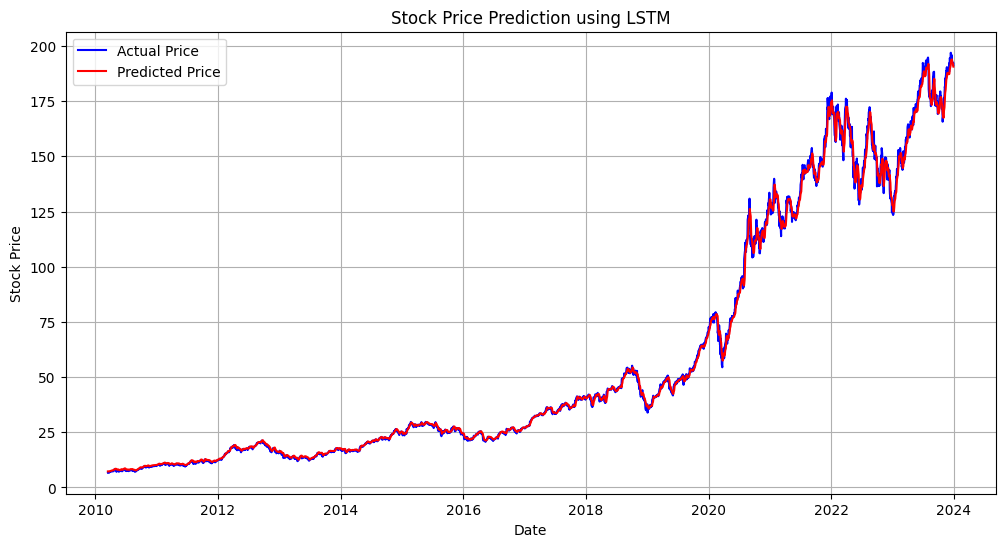

In [6]:
# Make predictions
predictions = model.predict(X)
predictions = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y.reshape(-1, 1))

# Convert date_labels to pandas datetime format for better plotting
date_labels = pd.to_datetime(date_labels)

# Plot actual vs predicted prices with Date
plt.figure(figsize=(12,6))
plt.plot(date_labels, actual_prices, label="Actual Price", color='blue')
plt.plot(date_labels, predictions, label="Predicted Price", color='red')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediction using LSTM')
plt.legend()
plt.grid()
plt.show()


In [7]:
# Get the last 50 days of data
last_50_days = scaled_data[-50:]
last_50_days = last_50_days.reshape(1, 50, 1)

# Predict the next 10 days
future_predictions = []
future_dates = pd.date_range(start=date_labels[-1], periods=11, freq='B')[1:]  # Next 10 business days

for i in range(10):
    predicted_price = model.predict(last_50_days)
    future_predictions.append(predicted_price[0][0])  # Save predicted value

    # Update input data with the new predicted value
    new_input = np.append(last_50_days[:, 1:, :], [[[predicted_price[0][0]]]], axis=1)
    last_50_days = new_input  # Slide the window forward

# Convert predictions back to original scale
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


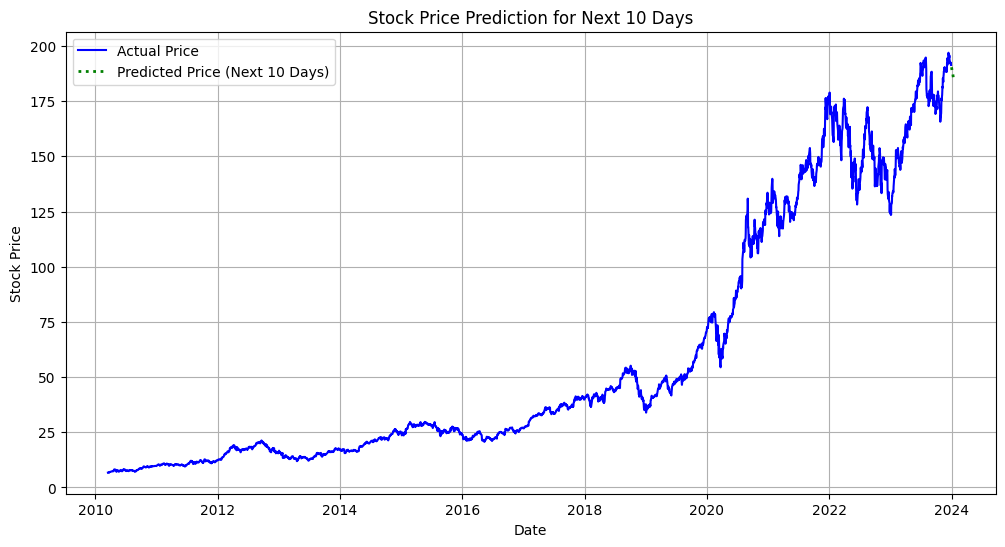

In [13]:
# Plot past actual prices
plt.figure(figsize=(12,6))
plt.plot(date_labels, actual_prices, label="Actual Price", color='blue')

# Plot predicted prices for next 10 days
plt.plot(future_dates, future_predictions, label="Predicted Price (Next 10 Days)", color='green', linestyle='dotted',linewidth=2)

plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediction for Next 10 Days')
plt.legend()
plt.grid()
plt.show()
